# Hypothesentests – Bank-Telemarketing-Datensatz

Dieses Notebook testet vier Hypothesen zum Bank-Telemarketing-Datensatz.  
Jede Hypothese wird – soweit kontextlich sinnvoll – **getrennt** für zwei Teilmengen ausgewertet:

| Datensatz | Beschreibung | Filter |
|-----------|-------------|--------|
| **Erstkontaktierte** (`firsts`) | Kunden ohne vorherigen Kontakt | `previous == 0` |
| **Bereits Kontaktierte** (`previous`) | Kunden mit mind. einem früheren Kontakt | `previous > 0` |

**Hypothesen:**
1. Je mehr Kontaktversuche in dieser Kampagne (`campaign`), desto unwahrscheinlicher der Abschluss.
2. Kunden mit Immobilienkredit (`housing=yes`) **und** persönlichem Kredit (`loan=yes`) schließen seltener ab.
3. Kunden, bei denen die vorherige Kampagne erfolgreich war (`poutcome=success`), schließen signifikant häufiger ab.
4. Kunden in Berufsgruppen mit höherem/gesichertem Einkommen (Management, Rentner) schließen signifikant häufiger ab als Blue-Collar-Arbeiter.

**Signifikanzniveau:** α = 0,05 für alle Tests.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency, pointbiserialr, spearmanr

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', 40)

print('Imports erfolgreich geladen.')

Imports erfolgreich geladen.


In [2]:

df_firsts   = pd.read_csv('data_firsts_final.csv')
df_previous = pd.read_csv('data_previous_final.csv')

df_firsts['y_int']   = df_firsts['y'].astype(int)
df_previous['y_int'] = df_previous['y'].astype(int)

if 'poutcome_success' in df_previous.columns:
    df_previous['poutcome'] = np.where(
        df_previous['poutcome_success'] == True, 'success',
        np.where(df_previous['poutcome_other'] == True, 'other', 'failure')
    )

common_cols = sorted(set(df_firsts.columns) & set(df_previous.columns))
df_all = pd.concat([df_firsts[common_cols], df_previous[common_cols]], ignore_index=True)

print(f'Erstkontaktierte:       {len(df_firsts):>6} Zeilen')
print(f'Bereits Kontaktierte:   {len(df_previous):>6} Zeilen')
print(f'Gesamt:                 {len(df_all):>6} Zeilen')
print()
print(f'Abschlussrate firsts:   {df_firsts["y_int"].mean()*100:.2f} %')
print(f'Abschlussrate previous: {df_previous["y_int"].mean()*100:.2f} %')
print(f'Abschlussrate gesamt:   {df_all["y_int"].mean()*100:.2f} %')

Erstkontaktierte:        36954 Zeilen
Bereits Kontaktierte:     8251 Zeilen
Gesamt:                  45205 Zeilen

Abschlussrate firsts:   9.16 %
Abschlussrate previous: 23.06 %
Abschlussrate gesamt:   11.70 %


---
## Hypothese 1: Mehr Kontaktversuche → geringere Abschlusswahrscheinlichkeit

**H₀:** Es gibt keinen Zusammenhang zwischen der Anzahl der Kontaktversuche (`campaign_log`) und dem Abschluss (`y`).  
**H₁:** Je mehr Kontaktversuche, desto unwahrscheinlicher der Abschluss (negativer Zusammenhang).

**Methode:**
- Point-Biserial-Korrelation (metrisch vs. binär)
- Spearman-Rangkorrelation (robuster gegenüber Nicht-Normalverteilung)
- Mann-Whitney-U-Test (Vergleich der Campaign-Verteilungen zwischen y=0 und y=1)

*Hinweis:* `campaign_log` ist die log-transformierte Anzahl der Kontaktversuche.

In [3]:
def test_hypothese1(df, label):
    """Testet H1: campaign_log vs. y"""
    print(f'\n{"=" * 60}')
    print(f'  Hypothese 1 – {label}')
    print(f'{"=" * 60}')
    
    if df.empty:
        print(' Keine Daten vorhanden.')
        return np.nan, np.nan
    
    # Deskriptive Statistik
    for val, lbl in [(True, 'Abschluss (y=1)'), (False, 'Kein Abschluss (y=0)')]:
        subset = df.loc[df['y'] == val, 'campaign_log']
        print(f'  {lbl}: M={subset.mean():.4f}, Md={subset.median():.4f}, '
              f'SD={subset.std():.4f}, n={len(subset)}')
    
    # Point-Biserial-Korrelation
    r_pb, p_pb = pointbiserialr(df['y_int'], df['campaign_log'])
    print(f'\n  Point-Biserial r = {r_pb:.4f},  p = {p_pb:.2e}')
    
    # Spearman-Korrelation
    rho, p_sp = spearmanr(df['campaign_log'], df['y_int'])
    print(f'  Spearman ρ       = {rho:.4f},  p = {p_sp:.2e}')
    
    # Mann-Whitney-U
    grp_yes = df.loc[df['y'] == True,  'campaign_log']
    grp_no  = df.loc[df['y'] == False, 'campaign_log']
    u_stat, p_mw = mannwhitneyu(grp_yes, grp_no, alternative='less')
    print(f'  Mann-Whitney U   = {u_stat:.0f},  p (einseitig) = {p_mw:.2e}')
    
    # Interpretation
    if r_pb < 0 and p_pb < 0.05:
        print(f'\n  H1 bestätigt: Signifikant negativer Zusammenhang (r={r_pb:.4f}).')
        print(f'     Mehr Kontaktversuche gehen mit geringerer Abschlussrate einher.')
    else:
        print(f'\n  H1 nicht bestätigt auf α=0.05.')
    
    return r_pb, p_pb

r1_f, p1_f = test_hypothese1(df_firsts, 'Erstkontaktierte')
r1_p, p1_p = test_hypothese1(df_previous, 'Bereits Kontaktierte')


  Hypothese 1 – Erstkontaktierte
  Abschluss (y=1): M=1.0807, Md=1.0986, SD=0.4525, n=3384
  Kein Abschluss (y=0): M=1.1991, Md=1.0986, SD=0.5354, n=33570

  Point-Biserial r = -0.0645,  p = 2.47e-35
  Spearman ρ       = -0.0630,  p = 8.60e-34
  Mann-Whitney U   = 49906555,  p (einseitig) = 4.97e-34

  H1 bestätigt: Signifikant negativer Zusammenhang (r=-0.0645).
     Mehr Kontaktversuche gehen mit geringerer Abschlussrate einher.

  Hypothese 1 – Bereits Kontaktierte
  Abschluss (y=1): M=0.9600, Md=0.6931, SD=0.3390, n=1903
  Kein Abschluss (y=0): M=1.0454, Md=1.0986, SD=0.4114, n=6348

  Point-Biserial r = -0.0906,  p = 1.67e-16
  Spearman ρ       = -0.0789,  p = 7.12e-13
  Mann-Whitney U   = 5433514,  p (einseitig) = 3.85e-13

  H1 bestätigt: Signifikant negativer Zusammenhang (r=-0.0906).
     Mehr Kontaktversuche gehen mit geringerer Abschlussrate einher.


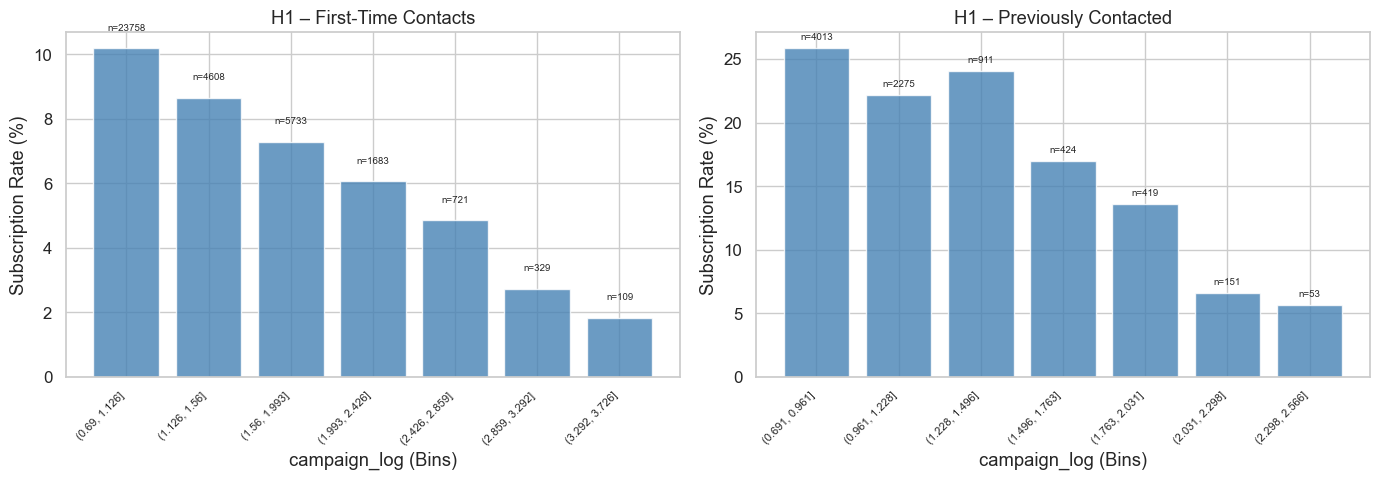

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_sub, label in [(axes[0], df_firsts, 'First-Time Contacts'),
                           (axes[1], df_previous, 'Previously Contacted')]:
    df_temp = df_sub.copy()

    if df_temp.empty or 'campaign_log' not in df_temp.columns:
        ax.set_title(f'H1 – {label}\n(no data)')
        continue

    df_temp = df_temp.dropna(subset=['campaign_log'])
    if len(df_temp) == 0:
        ax.set_title(f'H1 – {label}\n(no data)')
        continue

    df_temp['campaign_bin'] = pd.cut(df_temp['campaign_log'], bins=8)
    grouped = df_temp.groupby('campaign_bin', observed=True)['y_int'].agg(['mean', 'count'])
    grouped = grouped[grouped['count'] >= 20]

    ax.bar(range(len(grouped)), grouped['mean'] * 100, color='steelblue', alpha=0.8)
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels([str(x) for x in grouped.index], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Subscription Rate (%)')
    ax.set_xlabel('campaign_log (Bins)')
    ax.set_title(f'H1 – {label}')

    for i, (rate, n) in enumerate(zip(grouped['mean'], grouped['count'])):
        ax.text(i, rate * 100 + 0.5, f'n={n}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('h1_campaign_vs_subscription.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Hypothese 2: Immobilienkredit + Personalkredit → geringere Abschlussrate

**H₀:** Die Abschlussrate unterscheidet sich nicht zwischen Kunden mit beiden Krediten und den übrigen Kunden.  
**H₁:** Kunden mit `housing=yes` **und** `loan=yes` schließen seltener ab.

**Methode:**
- Chi²-Unabhängigkeitstest (2×2-Kontingenztafel)
- Cramér's V als Effektstärkemaß

In [5]:
def test_hypothese2(df, label):
    """Testet H2: housing=yes AND loan=yes vs. y"""
    print(f'\n{"=" * 60}')
    print(f'  Hypothese 2 – {label}')
    print(f'{"=" * 60}')
    
    # Gruppe: beide Kredite vs. Rest
    df = df.copy()
    df['both_credits'] = (df['housing_yes'] == True) & (df['loan_yes'] == True)
    
    # Kreuztabelle
    ct = pd.crosstab(df['both_credits'], df['y'], margins=True)
    ct.index = ['Nicht beide Kredite', 'Beide Kredite', 'Gesamt']
    ct.columns = ['Kein Abschluss', 'Abschluss', 'Gesamt']
    print(f'\n  Kontingenztafel:')
    print(ct.to_string().replace('\n', '\n  '))
    
    # Abschlussraten
    rate_both = df.loc[df['both_credits'], 'y_int'].mean() * 100
    rate_rest = df.loc[~df['both_credits'], 'y_int'].mean() * 100
    print(f'\n  Abschlussrate beide Kredite: {rate_both:.2f} %')
    print(f'  Abschlussrate Rest:          {rate_rest:.2f} %')
    print(f'  Differenz:                   {rate_rest - rate_both:.2f} Prozentpunkte')
    
    # Chi²-Test
    ct_raw = pd.crosstab(df['both_credits'], df['y'])
    chi2, p_chi, dof, expected = chi2_contingency(ct_raw)
    n = len(df)
    cramers_v = np.sqrt(chi2 / (n * (min(ct_raw.shape) - 1)))
    
    print(f'\n  Chi² = {chi2:.2f},  df = {dof},  p = {p_chi:.2e}')
    print(f'  Cramér\'s V = {cramers_v:.4f}')
    
    if p_chi < 0.05 and rate_both < rate_rest:
        print(f'\n  H2 bestätigt: Kunden mit beiden Krediten schließen signifikant seltener ab.')
        print(f'     Effektstärke (Cramér\'s V = {cramers_v:.4f}) ist '
              f'{"klein" if cramers_v < 0.1 else "mittel" if cramers_v < 0.3 else "groß"}.')
    elif p_chi < 0.05:
        print(f'\n  Signifikanter Unterschied, aber entgegen der Hypothesenrichtung.')
    else:
        print(f'\n  H2 nicht bestätigt auf α=0.05.')
    
    return chi2, p_chi, cramers_v

c2_f, p2_f, v2_f = test_hypothese2(df_firsts, 'Erstkontaktierte')
c2_p, p2_p, v2_p = test_hypothese2(df_previous, 'Bereits Kontaktierte')


  Hypothese 2 – Erstkontaktierte

  Kontingenztafel:
                     Kein Abschluss  Abschluss  Gesamt
  Nicht beide Kredite           30241       3196   33437
  Beide Kredite                  3329        188    3517
  Gesamt                        33570       3384   36954

  Abschlussrate beide Kredite: 5.35 %
  Abschlussrate Rest:          9.56 %
  Differenz:                   4.21 Prozentpunkte

  Chi² = 67.39,  df = 1,  p = 2.23e-16
  Cramér's V = 0.0427

  H2 bestätigt: Kunden mit beiden Krediten schließen signifikant seltener ab.
     Effektstärke (Cramér's V = 0.0427) ist klein.

  Hypothese 2 – Bereits Kontaktierte

  Kontingenztafel:
                     Kein Abschluss  Abschluss  Gesamt
  Nicht beide Kredite            5576       1827    7403
  Beide Kredite                   772         76     848
  Gesamt                         6348       1903    8251

  Abschlussrate beide Kredite: 8.96 %
  Abschlussrate Rest:          24.68 %
  Differenz:                   15.72 Pr

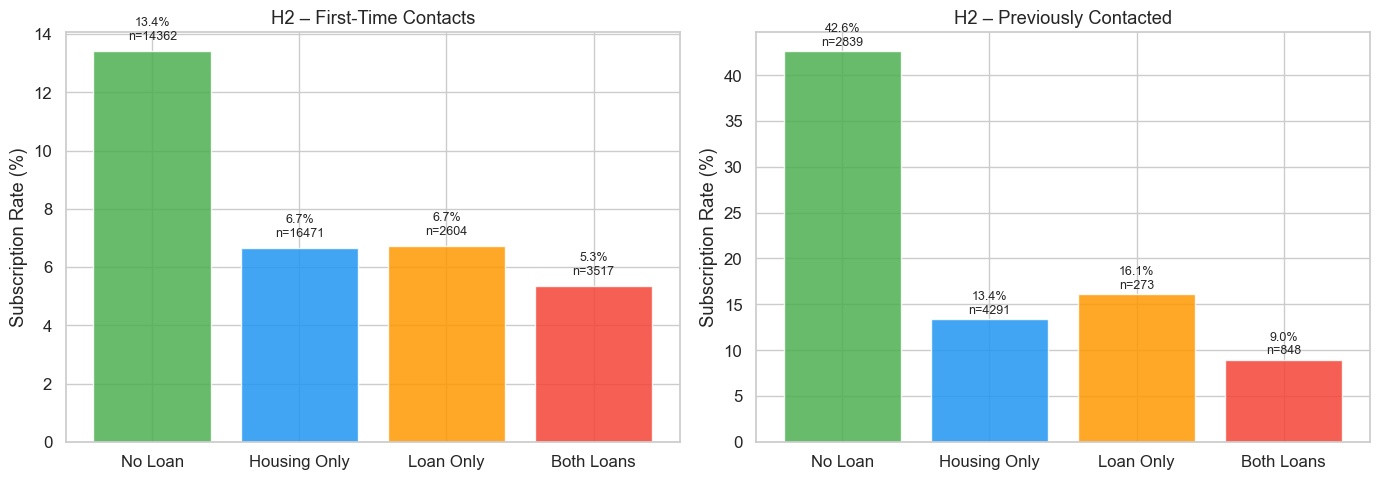

In [6]:
# ── Visualization Hypothesis 2 ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_sub, label in [(axes[0], df_firsts, 'First-Time Contacts'),
                           (axes[1], df_previous, 'Previously Contacted')]:
    df_temp = df_sub.copy()
    df_temp['both_credits'] = (df_temp['housing_yes'] == True) & (df_temp['loan_yes'] == True)
    
    # Four groups: housing × loan
    conditions = [
        ('No Loan',       (df_temp['housing_yes']==False) & (df_temp['loan_yes']==False)),
        ('Housing Only',  (df_temp['housing_yes']==True)  & (df_temp['loan_yes']==False)),
        ('Loan Only',     (df_temp['housing_yes']==False) & (df_temp['loan_yes']==True)),
        ('Both Loans',    (df_temp['housing_yes']==True)  & (df_temp['loan_yes']==True)),
    ]
    
    labels_bar = []
    rates = []
    counts = []
    for lbl_bar, mask in conditions:
        sub = df_temp.loc[mask]
        labels_bar.append(lbl_bar)
        rates.append(sub['y_int'].mean() * 100)
        counts.append(len(sub))
    
    colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
    bars = ax.bar(labels_bar, rates, color=colors, alpha=0.85)
    ax.set_ylabel('Subscription Rate (%)')
    ax.set_title(f'H2 – {label}')
    
    for bar, rate, n in zip(bars, rates, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{rate:.1f}%\nn={n}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('h2_credits_vs_subscription.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Hypothese 3: Erfolgreiche vorherige Kampagne → höhere Abschlussrate

**H₀:** Die Abschlussrate unterscheidet sich nicht zwischen Kunden mit `poutcome=success` und den übrigen.  
**H₁:** Kunden mit `poutcome=success` schließen signifikant häufiger ab.

**Methode:**
- Chi²-Test
- Cramér's V

*Diese Hypothese wird nur für bereits kontaktierte Kunden (`previous > 0`) ausgewertet, da nur diese einen sinnvollen `poutcome`-Wert haben. Erstkontaktierte haben durchgehend `poutcome=unknown`.*

In [7]:
def test_hypothese3(df, label, has_poutcome=True):
    """Testet H3: poutcome_success vs. y"""
    print(f'\n{"=" * 60}')
    print(f'  Hypothese 3 – {label}')
    print(f'{"=" * 60}')
    
    if not has_poutcome or 'poutcome_success' not in df.columns:
        print(f'\n  Keine poutcome-Spalte vorhanden (Erstkontaktierte haben keinen vorherigen')
        print(f'     Kampagnenkontakt). Test nicht anwendbar.')
        return None, None, None
    
    df = df.copy()
    
    n_success = df['poutcome_success'].sum()
    n_other   = df['poutcome_other'].sum() if 'poutcome_other' in df.columns else 0
    n_failure = len(df) - n_success - n_other
    
    print(f'\n  poutcome-Verteilung:')
    print(f'    failure: n={n_failure:>5}  → Abschlussrate = '
          f'{df.loc[(df["poutcome_success"]==False) & (df.get("poutcome_other", pd.Series(False))==False), "y_int"].mean()*100:.2f} %')
    if 'poutcome_other' in df.columns:
        print(f'      other: n={n_other:>5}  → Abschlussrate = '
              f'{df.loc[df["poutcome_other"]==True, "y_int"].mean()*100:.2f} %')
    print(f'    success: n={n_success:>5}  → Abschlussrate = '
          f'{df.loc[df["poutcome_success"]==True, "y_int"].mean()*100:.2f} %')
    
    rate_success = df.loc[df['poutcome_success'] == True, 'y_int'].mean() * 100
    rate_rest    = df.loc[df['poutcome_success'] == False, 'y_int'].mean() * 100
    print(f'\n  Abschlussrate poutcome=success: {rate_success:.2f} %')
    print(f'  Abschlussrate Rest:             {rate_rest:.2f} %')
    print(f'  Differenz:                      {rate_success - rate_rest:.2f} Prozentpunkte')
    
    ct = pd.crosstab(df['poutcome_success'], df['y'])
    chi2, p_chi, dof, expected = chi2_contingency(ct)
    n = len(df)
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    
    print(f'\n  Chi² = {chi2:.2f},  df = {dof},  p = {p_chi:.2e}')
    print(f'  Cramér\'s V = {cramers_v:.4f}')
    
    if p_chi < 0.05 and rate_success > rate_rest:
        print(f'\n  H3 bestätigt: Kunden mit poutcome=success schließen signifikant häufiger ab.')
        print(f'     Effektstärke (Cramér\'s V = {cramers_v:.4f}) ist '
              f'{"klein" if cramers_v < 0.1 else "mittel" if cramers_v < 0.3 else "groß"}.')
    else:
        print(f'\n  H3 nicht bestätigt auf α=0.05.')
    
    return chi2, p_chi, cramers_v

# Nur für already-contacted sinnvoll
print('Hypothese 3 ist nur für bereits kontaktierte Kunden sinnvoll auswertbar,')
print('    da Erstkontaktierte keinen vorherigen Kampagnenerfolg haben können.')

c3_f, p3_f, v3_f = test_hypothese3(df_firsts, 'Erstkontaktierte', has_poutcome=False)
c3_p, p3_p, v3_p = test_hypothese3(df_previous, 'Bereits Kontaktierte', has_poutcome=True)

Hypothese 3 ist nur für bereits kontaktierte Kunden sinnvoll auswertbar,
    da Erstkontaktierte keinen vorherigen Kampagnenerfolg haben können.

  Hypothese 3 – Erstkontaktierte

  Keine poutcome-Spalte vorhanden (Erstkontaktierte haben keinen vorherigen
     Kampagnenkontakt). Test nicht anwendbar.

  Hypothese 3 – Bereits Kontaktierte

  poutcome-Verteilung:
    failure: n= 4901  → Abschlussrate = 12.61 %
      other: n= 1839  → Abschlussrate = 16.69 %
    success: n= 1511  → Abschlussrate = 64.73 %

  Abschlussrate poutcome=success: 64.73 %
  Abschlussrate Rest:             13.72 %
  Differenz:                      51.00 Prozentpunkte

  Chi² = 1806.46,  df = 1,  p = 0.00e+00
  Cramér's V = 0.4679

  H3 bestätigt: Kunden mit poutcome=success schließen signifikant häufiger ab.
     Effektstärke (Cramér's V = 0.4679) ist groß.


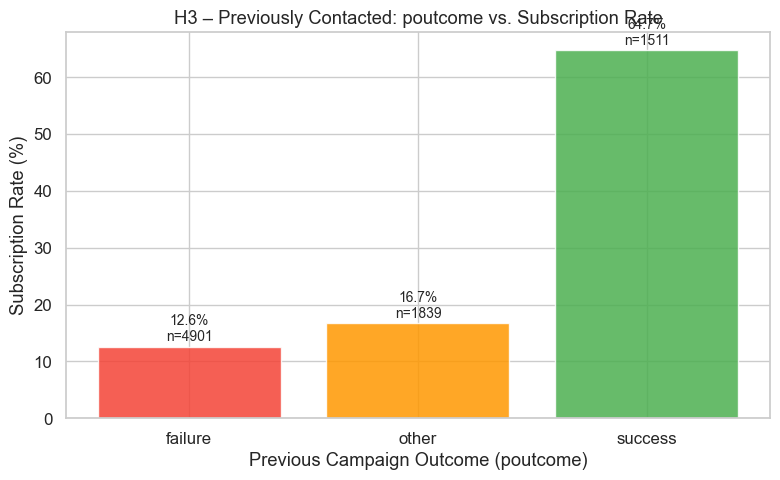

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

df_temp = df_previous.copy()

categories = []
rates_h3 = []
counts_h3 = []
colors_h3 = []

mask_failure = (df_temp['poutcome_success'] == False) & (df_temp['poutcome_other'] == False)
categories.append('failure')
rates_h3.append(df_temp.loc[mask_failure, 'y_int'].mean() * 100)
counts_h3.append(mask_failure.sum())
colors_h3.append('#F44336')

mask_other = df_temp['poutcome_other'] == True
categories.append('other')
rates_h3.append(df_temp.loc[mask_other, 'y_int'].mean() * 100)
counts_h3.append(mask_other.sum())
colors_h3.append('#FF9800')

mask_success = df_temp['poutcome_success'] == True
categories.append('success')
rates_h3.append(df_temp.loc[mask_success, 'y_int'].mean() * 100)
counts_h3.append(mask_success.sum())
colors_h3.append('#4CAF50')

bars = ax.bar(categories, rates_h3, color=colors_h3, alpha=0.85)

for bar, rate, n in zip(bars, rates_h3, counts_h3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{rate:.1f}%\nn={n}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Subscription Rate (%)')
ax.set_xlabel('Previous Campaign Outcome (poutcome)')
ax.set_title('H3 – Previously Contacted: poutcome vs. Subscription Rate')

plt.tight_layout()
plt.savefig('h3_poutcome_vs_subscription.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Hypothese 4: Höheres Einkommen (Berufsgruppe) → höhere Abschlussrate

**H₀:** Die Abschlussrate unterscheidet sich nicht zwischen Management/Rentner und Blue-Collar-Arbeitern.  
**H₁:** Management und Rentner schließen signifikant häufiger ab als Blue-Collar-Arbeiter.

**Methode:**
- Chi²-Test (3×2-Kontingenztafel: Management, Retired, Blue-Collar × y)
- Paarweise Vergleiche: Management vs. Blue-Collar, Retired vs. Blue-Collar
- Bonferroni-Korrektur für multiple Tests (α_adj = 0,025)

In [ ]:
def test_hypothese4(df, label):
    """Testet H4: Management/Retired vs. Blue-Collar"""
    print(f'\n{"=" * 60}')
    print(f'  Hypothese 4 – {label}')
    print(f'{"=" * 60}')
    
    job_cols = [c for c in df.columns if c.startswith('job_')]
    df = df.copy()
    df['job'] = 'admin' 
    for col in job_cols:
        job_name = col.replace('job_', '')
        df.loc[df[col] == True, 'job'] = job_name
    
    print(f'\n  Abschlussraten nach Berufsgruppe:')
    job_stats = df.groupby('job')['y_int'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    job_stats['mean'] = job_stats['mean'] * 100
    job_stats.columns = ['Abschlussrate (%)', 'n']
    print(job_stats.to_string().replace('\n', '\n  '))
    
    high_income = ['management', 'retired']
    df_mgmt  = df[df['job'] == 'management']
    df_ret   = df[df['job'] == 'retired']
    df_bc    = df[df['job'] == 'blue-collar']
    df_high  = df[df['job'].isin(high_income)]
    
    rate_mgmt = df_mgmt['y_int'].mean() * 100
    rate_ret  = df_ret['y_int'].mean() * 100
    rate_bc   = df_bc['y_int'].mean() * 100
    
    print(f'\n  Management:   {rate_mgmt:.2f} % (n={len(df_mgmt)})')
    print(f'  Rentner:      {rate_ret:.2f} % (n={len(df_ret)})')
    print(f'  Blue-Collar:  {rate_bc:.2f} % (n={len(df_bc)})')
    
    df_3groups = df[df['job'].isin(['management', 'retired', 'blue-collar'])]
    ct = pd.crosstab(df_3groups['job'], df_3groups['y'])
    chi2, p_chi, dof, expected = chi2_contingency(ct)
    n = len(df_3groups)
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    
    print(f'\n  Globaler Chi²-Test (Management vs. Retired vs. Blue-Collar):')
    print(f'  Chi² = {chi2:.2f},  df = {dof},  p = {p_chi:.2e}')
    print(f'  Cramér\'s V = {cramers_v:.4f}')
    
    alpha_adj = 0.05 / 2 
    print(f'\n  Paarweise Vergleiche (Bonferroni-korrigiert, α_adj = {alpha_adj}):')
    
    results = []
    for lbl, df_test in [('Management vs. Blue-Collar', pd.concat([df_mgmt, df_bc])),
                          ('Rentner vs. Blue-Collar', pd.concat([df_ret, df_bc]))]:
        ct_pair = pd.crosstab(df_test['job'], df_test['y'])
        chi2_p, p_p, dof_p, _ = chi2_contingency(ct_pair)
        n_p = len(df_test)
        v_p = np.sqrt(chi2_p / (n_p * (min(ct_pair.shape) - 1)))
        sig = '✅' if p_p < alpha_adj else '❌'
        print(f'    {sig} {lbl}: Chi²={chi2_p:.2f}, p={p_p:.2e}, V={v_p:.4f}')
        results.append((chi2_p, p_p, v_p))
    
    if p_chi < 0.05:
        print(f'\n  H4 bestätigt: Signifikante Unterschiede zwischen Berufsgruppen.')
    else:
        print(f'\n  H4 nicht bestätigt auf α=0.05.')
    
    return chi2, p_chi, cramers_v

c4_f, p4_f, v4_f = test_hypothese4(df_firsts, 'Erstkontaktierte')
c4_p, p4_p, v4_p = test_hypothese4(df_previous, 'Bereits Kontaktierte')


  Hypothese 4 – Erstkontaktierte

  Abschlussraten nach Berufsgruppe:
               Abschlussrate (%)     n
  job                                   
  student                22.970904   653
  retired                17.454955  1776
  unemployed             11.009174  1090
  management             10.207023  7632
  self-employed           9.399076  1298
  admin                   9.358158  4082
  technician              8.920863  6255
  entrepreneur            7.606973  1262
  services                7.250580  3448
  unknown                 7.058824   255
  housemaid               6.893382  1088
  blue-collar             6.457178  8115

  Management:   10.21 % (n=7632)
  Rentner:      17.45 % (n=1776)
  Blue-Collar:  6.46 % (n=8115)

  Globaler Chi²-Test (Management vs. Retired vs. Blue-Collar):
  Chi² = 227.11,  df = 2,  p = 4.82e-50
  Cramér's V = 0.1138

  Paarweise Vergleiche (Bonferroni-korrigiert, α_adj = 0.025):
    ✅ Management vs. Blue-Collar: Chi²=72.37, p=1.78e-17, V=0.0678
 

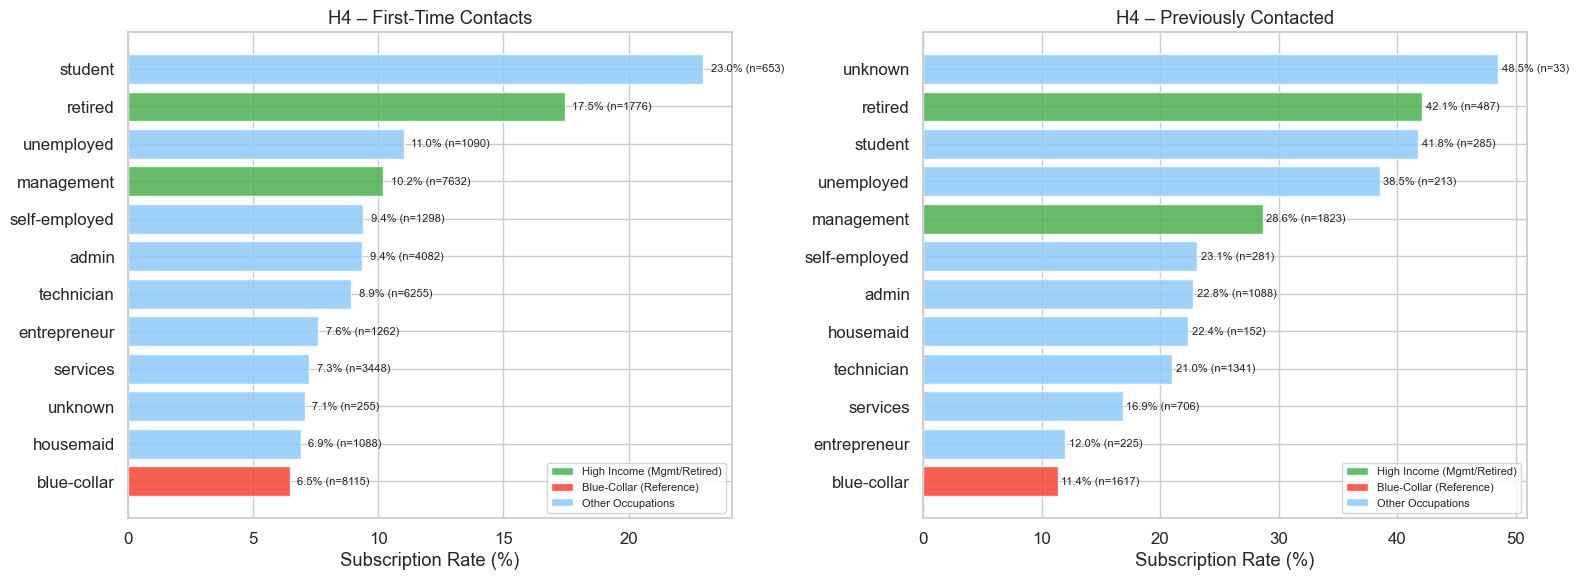

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, df_sub, label in [(axes[0], df_firsts, 'First-Time Contacts'),
                           (axes[1], df_previous, 'Previously Contacted')]:
    df_temp = df_sub.copy()
    job_cols = [c for c in df_temp.columns if c.startswith('job_')]
    df_temp['job'] = 'admin'
    for col in job_cols:
        job_name = col.replace('job_', '')
        df_temp.loc[df_temp[col] == True, 'job'] = job_name
    
    job_rates = df_temp.groupby('job')['y_int'].agg(['mean', 'count'])
    job_rates = job_rates.sort_values('mean', ascending=True)
    
    colors = []
    for job in job_rates.index:
        if job in ['management', 'retired']:
            colors.append('#4CAF50') 
        elif job == 'blue-collar':
            colors.append('#F44336')  
        else:
            colors.append('#90CAF9') 
    
    bars = ax.barh(job_rates.index, job_rates['mean'] * 100, color=colors, alpha=0.85)
    ax.set_xlabel('Subscription Rate (%)')
    ax.set_title(f'H4 – {label}')
    
    for bar, (_, row) in zip(bars, job_rates.iterrows()):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{row["mean"]*100:.1f}% (n={int(row["count"])})',
                va='center', fontsize=8)
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#4CAF50', alpha=0.85, label='High Income (Mgmt/Retired)'),
        Patch(facecolor='#F44336', alpha=0.85, label='Blue-Collar (Reference)'),
        Patch(facecolor='#90CAF9', alpha=0.85, label='Other Occupations'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('h4_job_groups_vs_subscription.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Zusammenfassung aller Hypothesentests

In [ ]:
print('=' * 90)
print('  ZUSAMMENFASSUNG DER HYPOTHESENTESTS')
print('=' * 90)

rows = []

for lbl, r, p in [('Erstkontaktierte', r1_f, p1_f), ('Bereits Kontaktierte', r1_p, p1_p)]:
    if np.isnan(r):
        rows.append(('H1: Mehr Kontakte → weniger Abschlüsse', lbl, 'n/a', 'n/a', '–'))
    else:
        rows.append(('H1: Mehr Kontakte → weniger Abschlüsse', lbl,
                      f'r={r:.4f}', f'{p:.2e}',
                      '✅' if (r < 0 and p < 0.05) else '❌'))

for lbl, c, p in [('Erstkontaktierte', c2_f, p2_f), ('Bereits Kontaktierte', c2_p, p2_p)]:
    rows.append(('H2: Beide Kredite → weniger Abschlüsse', lbl,
                  f'χ²={c:.2f}', f'{p:.2e}',
                  '✅' if p < 0.05 else '❌'))

if c3_p is not None:
    rows.append(('H3: poutcome=success → mehr Abschlüsse', 'Bereits Kontaktierte',
                  f'χ²={c3_p:.2f}', f'{p3_p:.2e}',
                  '✅' if p3_p < 0.05 else '❌'))
else:
    rows.append(('H3: poutcome=success → mehr Abschlüsse', 'Bereits Kontaktierte',
                  'n/a', 'n/a', '–'))

for lbl, c, p in [('Erstkontaktierte', c4_f, p4_f), ('Bereits Kontaktierte', c4_p, p4_p)]:
    rows.append(('H4: Mgmt/Rentner > Blue-Collar', lbl,
                  f'χ²={c:.2f}', f'{p:.2e}',
                  '✅' if p < 0.05 else '❌'))

df_summary = pd.DataFrame(rows, columns=['Hypothese', 'Datensatz', 'Teststatistik', 'p-Wert', 'Ergebnis'])
print()
print(df_summary.to_string(index=False))
print()
print('Signifikanzniveau: α = 0.05')
print('✅ = Hypothese bestätigt (signifikant)  |  ❌ = Hypothese nicht bestätigt')

  ZUSAMMENFASSUNG DER HYPOTHESENTESTS

                             Hypothese            Datensatz Teststatistik   p-Wert Ergebnis
H1: Mehr Kontakte → weniger Abschlüsse     Erstkontaktierte     r=-0.0645 2.47e-35        ✅
H1: Mehr Kontakte → weniger Abschlüsse Bereits Kontaktierte     r=-0.0906 1.67e-16        ✅
H2: Beide Kredite → weniger Abschlüsse     Erstkontaktierte      χ²=67.39 2.23e-16        ✅
H2: Beide Kredite → weniger Abschlüsse Bereits Kontaktierte     χ²=105.03 1.20e-24        ✅
H3: poutcome=success → mehr Abschlüsse Bereits Kontaktierte    χ²=1806.46 0.00e+00        ✅
        H4: Mgmt/Rentner > Blue-Collar     Erstkontaktierte     χ²=227.11 4.82e-50        ✅
        H4: Mgmt/Rentner > Blue-Collar Bereits Kontaktierte     χ²=254.62 5.14e-56        ✅

Signifikanzniveau: α = 0.05
✅ = Hypothese bestätigt (signifikant)  |  ❌ = Hypothese nicht bestätigt
